# Claim 1 Evaluation and the Two Gates

Scores the trained model against the full baseline ladder on the 2024 frame, audits the
query machinery that produces those scores, and reports both pre-registered gates. Both
gates fail, and most of this notebook is the work of making that failure attributable
rather than merely recorded.

Every number is read from an artifact committed under `results/model_evaluation` or `results/model_v1`.
Nothing here trains, scores, or recomputes.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.analysis import claim1_eval
from src.model import query

## Configuration

Artifact locations and the orderings used for every table below. The scored arm is the
`embedding_sgd_sgd_lr1` ensemble (embedding table on plain SGD, canonical build since 2026-09-03) and the frame is 2024, which is the selection season rather than the
test season.

In [2]:
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 140)

PHASE_E_DIR = REPO_ROOT / "results/model_evaluation"
PHASE_C_DIR = REPO_ROOT / "results/baseline_ladder"
PHASE_D_DIR = REPO_ROOT / "results/model_v1"
PHASE_F_DIR = REPO_ROOT / "results/process_calibration"

SCORED_ARM = "min_pa_sweep_embedding_sgd_sgd_lr1"
EVAL_SEASON = 2024

LADDER_ORDER = ["no_info_league_average", "trailing_raw", "trailing_bucketed", "eb_bivariate",
                "eb_book_rho_reference", "gbm_outcome", "gbm_full", "model_v1"]
STRATUM_ORDER = ["low", "medium", "high", "all"]


def load_e(name):
    """Read one committed Phase E artifact by filename."""
    return pd.read_csv(PHASE_E_DIR / name)


def load_json_e(name):
    """Read one committed Phase E JSON artifact by filename."""
    return json.loads((PHASE_E_DIR / name).read_text())


def load_f(name):
    """Read one committed Phase F artifact by filename."""
    return pd.read_csv(PHASE_F_DIR / name)


def load_json_f(name):
    """Read one committed Phase F summary by filename."""
    return json.loads((PHASE_F_DIR / name).read_text())


## The two gates as pre-registered

No numeric threshold was set in advance. An ordering claim holds only if the model beats
both C.2 and C.3 full on weighted rank correlation in the stratum claimed, by paired
difference with batter clustering and a 95 percent interval excluding zero. The RMSE gate is
set against C.3 full alone.

The platoon adoption rule is separate and stricter. It asks whether the model beats the
incumbent at predicting the platoon differential itself, not the two sides.

## The full ladder on the claim 1 metric

Every baseline rung plus the model, scored on the same frame against the same answer key.
RMSE is PA weighted and lower is better. No comparison is claimed from these absolute
numbers, because two models scored against the same noisy target cannot be separated that
way.

In [3]:
ladder = load_e(f"model_v1_claim1_scores_{SCORED_ARM}.csv")
ladder["model"] = pd.Categorical(ladder["model"], LADDER_ORDER, ordered=True)
ladder["stratum"] = pd.Categorical(ladder["stratum"], STRATUM_ORDER, ordered=True)
ladder.pivot_table(index="model", columns="stratum",
                   values="pa_weighted_rmse", observed=False).round(5)

/var/folders/pf/jgfmjd9j39z8dmn0hk1cgswh0000gn/T/ipykernel_78257/619744370.py:2: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  ladder["model"] = pd.Categorical(ladder["model"], LADDER_ORDER, ordered=True)


stratum,low,medium,high,all
model,,,,
no_info_league_average,0.06310,0.05142,0.04795,0.05171
trailing_raw,0.10542,0.06380,0.04312,0.06316
trailing_bucketed,0.06598,0.05852,0.04315,0.05131
eb_bivariate,0.06176,0.05062,0.04105,0.04743
eb_book_rho_reference,0.06198,0.05017,0.04100,0.04736
gbm_outcome,0.05943,0.05021,0.04096,0.04676
gbm_full,0.05868,0.04949,0.04081,0.04634


## Skill against the no information reference

The same errors expressed as the share of between hitter talent variance each rung captures.
Negative means worse than predicting the league average for everybody.

In [4]:
ladder.pivot_table(index="model", columns="stratum",
                   values="skill_vs_no_info", observed=False).round(4)

stratum,low,medium,high,all
model,,,,
no_info_league_average,0.0000,0.0000,0.0000,0.0000
trailing_raw,-5.1833,-1.7432,0.3709,-1.1485
trailing_bucketed,-0.2706,-0.9539,0.3689,0.0365
eb_bivariate,0.1216,0.0993,0.5182,0.3706
eb_book_rho_reference,0.1016,0.1544,0.5216,0.3764
gbm_outcome,0.3268,0.1497,0.5241,0.4265
gbm_full,0.3911,0.2375,0.5349,0.4602


## Rank correlation by rung and stratum

The ordering metric, weighted by the wOBA denominator. This is the column the ordering gate
is decided on.

In [5]:
ladder.pivot_table(index="model", columns="stratum",
                   values="rank_corr_weighted", observed=False).round(4)

stratum,low,medium,high,all
model,,,,
no_info_league_average,-0.0730,0.0508,0.1071,0.0151
trailing_raw,0.0416,0.1223,0.4899,0.3493
trailing_bucketed,-0.0594,0.1431,0.4896,0.3604
eb_bivariate,0.1389,0.1926,0.5089,0.4103
eb_book_rho_reference,0.1260,0.2016,0.5066,0.4096
gbm_outcome,0.0846,0.1811,0.4955,0.4041
gbm_full,0.1665,0.2615,0.5238,0.4417


## The same ladder against a second answer key

Everything above is scored against observed wOBA, which carries the batted ball luck the
model is not trying to predict. Rescoring against xwOBA asks whether the ranking survives an
answer key with less of that luck in it. The model's ordering advantage is larger here and
its level error is larger, which is the same level versus order split the paired gates
handle.

In [6]:
both_targets = load_e(f"model_v1_both_targets_{SCORED_ARM}.csv")
both_targets = both_targets[both_targets["stratum"] == "all"]
both_targets.pivot_table(index="model", columns="target",
                         values=["pa_weighted_rmse", "rank_corr_weighted"]).round(4)

pa_weighted_rmse         rank_corr_weighted        
target                                         woba   xwoba               woba   xwoba
model                                                                                 
eb_bivariate                                 0.0474  0.0381             0.4103  0.4864
eb_book_rho_reference                        0.0474  0.0381             0.4096  0.4856
gbm_full                                     0.0463  0.0369             0.4417  0.5389
gbm_outcome                                  0.0468  0.0382             0.4041  0.4793
min_pa_sweep_embedding_sgd_sgd_lr1           0.0469  0.0373             0.4458  0.5462
no_info_league_average                       0.0517  0.0448             0.0151 -0.0153
trailing_bucketed                            0.0513  0.0426             0.3604  0.4277
trailing_raw                                 0.0632  0.0566             0.3493  0.4206
trailing_xwoba                               0.0484  0.0379             0.4248  0.5360

## Noise floor share of squared error

The held out target is itself a small sample measurement, so errors add in quadrature and
every rung pays the same floor. In the low stratum the floor dominates, which is why real
differences compress into what reads as rounding.

In [7]:
floor = ladder[ladder["model"] == "no_info_league_average"].copy()
floor["floor_share_of_mse"] = floor["noise_floor"] ** 2 / floor["pa_weighted_rmse"] ** 2
floor.set_index("stratum")[["n_hitters", "pa_weighted_rmse", "noise_floor",
                            "model_rmse", "floor_share_of_mse"]].round(4)

,n_hitters,pa_weighted_rmse,noise_floor,model_rmse,floor_share_of_mse
stratum,,,,,
low,380,0.0631,0.0510,0.0371,0.6544
medium,280,0.0514,0.0427,0.0286,0.6903
high,489,0.0479,0.0334,0.0344,0.4848
all,1149,0.0517,0.0391,0.0338,0.5720


## The gate verdicts

The model against each of the two named opponents, paired and batter clustered. Positive
rank difference favours the model. A gate passes only when the interval excludes zero.

In [8]:
gates = load_e(f"model_v1_claim1_paired_{SCORED_ARM}.csv")
gates["stratum"] = pd.Categorical(gates["stratum"], STRATUM_ORDER, ordered=True)
gates.sort_values(["opponent", "stratum"])[
    ["opponent", "stratum", "n_hitters", "n_batters",
     "rank_a", "rank_b", "rank_difference", "ci_low_rank", "ci_high_rank",
     "rmse_difference", "ci_low_rmse", "ci_high_rmse"]].round(5).reset_index(drop=True)

,opponent,stratum,n_hitters,n_batters,rank_a,rank_b,rank_difference,ci_low_rank,ci_high_rank,rmse_difference,ci_low_rmse,ci_high_rmse
0,eb_bivariate,low,380,239,0.24659,0.13888,0.10770,-0.06942,0.28596,-0.00316,-0.00728,0.00102
1,eb_bivariate,medium,280,238,0.35063,0.19264,0.15800,0.01239,0.29402,-0.00350,-0.00591,-0.00088
2,eb_bivariate,high,489,318,0.48116,0.50889,-0.02773,-0.09363,0.03587,0.00163,0.00001,0.00325
3,eb_bivariate,all,1149,604,0.44579,0.41028,0.03551,-0.01770,0.09172,-0.00058,-0.00205,0.00086
4,gbm_full,low,380,239,0.24659,0.16650,0.08009,-0.06912,0.23889,-0.00008,-0.00330,0.00286
5,gbm_full,medium,280,238,0.35063,0.26153,0.08910,-0.01562,0.18629,-0.00237,-0.00444,-0.00035
6,gbm_full,high,489,318,0.48116,0.52384,-0.04268,-0.09927,0.01240,0.00187,0.00055,0.00323
7,gbm_full,all,1149,604,0.44579,0.44175,0.00404,-0.03159,0.04103,0.00051,-0.00057,0.00164


In [9]:
verdict = load_json_e(f"model_v1_claim1_verdict_{SCORED_ARM}.json")
print(json.dumps(verdict, indent=2)[:1200])

{
  "decisive_stratum": "low",
  "rmse_gate_vs_gbm_full": false,
  "ordering_gate_vs_both": false,
  "by_stratum": {
    "all": {
      "rmse_gate_vs_gbm_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "high": {
      "rmse_gate_vs_gbm_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "low": {
      "rmse_gate_vs_gbm_full": false,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    },
    "medium": {
      "rmse_gate_vs_gbm_full": true,
      "ordering_gate_vs_both": false,
      "n_comparisons": 2
    }
  },
  "debiased_mean_excess_removed": 0.00681357857717427,
  "debiased_rmse_difference": {
    "low": {
      "rmse_difference": 0.0016774169814130144,
      "ci_low": -0.002241718277667818,
      "ci_high": 0.005246172041882514
    },
    "medium": {
      "rmse_difference": -0.00283417067907029,
      "ci_low": -0.005357123680490543,
      "ci_high": -0.00036884181153202947
    },
    "high"

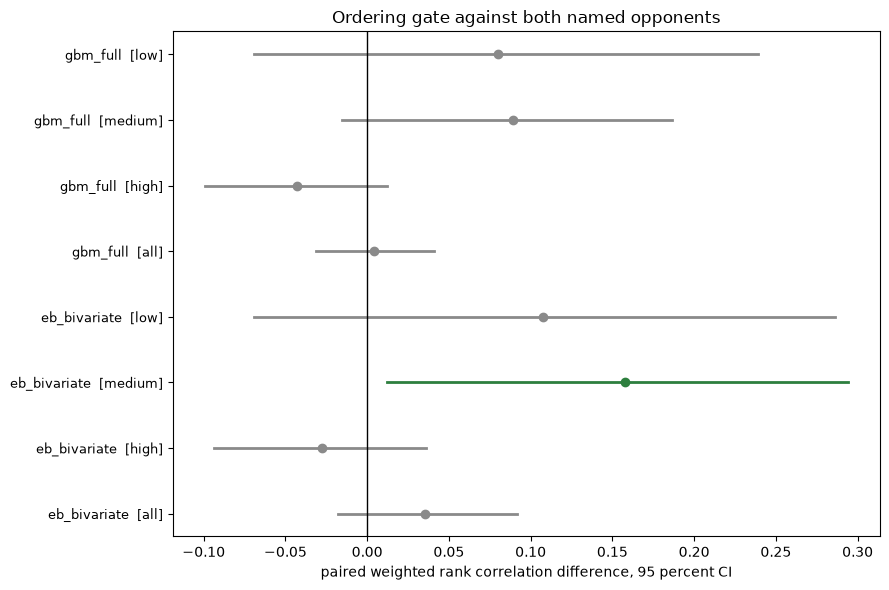

In [10]:
PASS_COLOR = "#2d7f3e"
FAIL_COLOR = "#8a8a8a"

plotted = gates.sort_values(["opponent", "stratum"], ascending=[True, False]).reset_index(drop=True)
figure, axis = plt.subplots(figsize=(9, 6))
for position, row in plotted.iterrows():
    excludes_zero = row["ci_low_rank"] > 0
    color = PASS_COLOR if excludes_zero else FAIL_COLOR
    axis.plot([row["ci_low_rank"], row["ci_high_rank"]], [position, position], color=color, lw=2)
    axis.plot(row["rank_difference"], position, "o", color=color, ms=6)
axis.axvline(0, color="black", lw=1)
axis.set_yticks(range(len(plotted)))
axis.set_yticklabels([f"{row.opponent}  [{row.stratum}]" for row in plotted.itertuples()],
                     fontsize=9)
axis.set_xlabel("paired weighted rank correlation difference, 95 percent CI")
axis.set_title("Ordering gate against both named opponents")
figure.tight_layout()
plt.show()

## Why the low stratum result is underpowered rather than absent

The model leads C.3 full on weighted rank in the low stratum by a margin larger than most
published effects, and the interval still spans zero. This restates the gap as the number of
batters that would be needed to resolve it.

In [11]:
power = load_e(f"model_v1_power_restatement_{SCORED_ARM}.csv")
power.set_index("stratum").round(4)

,n_batters,rank_difference,se_rank,z,batters_multiplier,batters_needed
stratum,,,,,,
low,239,0.0801,0.0786,1.0192,7.5558,1806
medium,238,0.0891,0.0515,1.7298,2.6230,624
high,318,-0.0427,0.0285,-1.4983,3.4962,1112
all,604,0.0040,0.0185,0.2182,164.7941,99536


## Noise floor deconvolution

The same head to head with the target noise removed from both sides, so the comparison is
between the models rather than between two measurements of a noisy answer key.

In [12]:
debiased = load_e(f"model_v1_claim1_debiased_{SCORED_ARM}.csv")
debiased["stratum"] = pd.Categorical(debiased["stratum"], STRATUM_ORDER, ordered=True)
debiased.sort_values(["opponent", "stratum"]).round(5).reset_index(drop=True)

,opponent,stratum,n_hitters,n_batters,rmse_a,rmse_b,rmse_difference,ci_low,ci_high,favours_a_share
0,gbm_full,low,380,239,0.06036,0.05868,0.00168,-0.00224,0.00525,0.2000
1,gbm_full,medium,280,238,0.04665,0.04949,-0.00283,-0.00536,-0.00037,0.9910
2,gbm_full,high,489,318,0.04121,0.04081,0.00041,-0.00098,0.00175,0.2875
3,gbm_full,all,1149,604,0.04635,0.04634,0.00001,-0.00125,0.00129,0.4970


In [13]:
achievable = load_e(f"model_v1_achievable_floor_{SCORED_ARM}.csv")
achievable.set_index("stratum").round(5)

,n_hitters,achievable_floor,xwoba_bias
stratum,,,
low,380,0.03640,0.00351
medium,280,0.03309,0.00407
high,489,0.02521,0.00634
all,1149,0.02923,0.00536


## The verdict across the censoring sweep

Every headline is reported across a three times swing in how much of the eval population the
PA floor removes. The verdict does not depend on the filter, and in the low stratum the gap
grows as the floor rises.

In [14]:
sweep = load_e("min_pa_sweep_b_min_pa_sweep.csv")
sweep["stratum"] = pd.Categorical(sweep["stratum"], STRATUM_ORDER, ordered=True)
sweep.sort_values(["opponent", "stratum", "min_eval_pa"])[
    ["min_eval_pa", "opponent", "stratum", "n_hitters", "n_batters",
     "rank_difference", "ci_low_rank", "ci_high_rank",
     "rmse_favours_model_v1", "rank_favours_model_v1"]].round(5).reset_index(drop=True)

,min_eval_pa,opponent,stratum,n_hitters,n_batters,rank_difference,ci_low_rank,ci_high_rank,rmse_favours_model_v1,rank_favours_model_v1
0,10,eb_bivariate,low,380,239,0.10770,-0.06942,0.28596,False,False
1,25,eb_bivariate,low,294,204,0.09892,-0.07930,0.27064,False,False
2,50,eb_bivariate,low,194,141,0.12318,-0.07873,0.32075,False,False
3,10,eb_bivariate,medium,280,238,0.15800,0.01239,0.29402,True,True
4,25,eb_bivariate,medium,250,218,0.16000,0.01477,0.30266,True,True
5,50,eb_bivariate,medium,210,183,0.17012,0.01857,0.31850,True,True
6,10,eb_bivariate,high,489,318,-0.02773,-0.09363,0.03587,False,False
7,25,eb_bivariate,high,469,309,-0.02880,-0.09591,0.03646,False,False
8,50,eb_bivariate,high,444,300,-0.02833,-0.09571,0.03919,False,False
9,10,eb_bivariate,all,1149,604,0.03551,-0.01770,0.09172,False,False


## The platoon adoption rule

The stricter claim, scored on the platoon differential itself rather than the two sides. No
stratum's paired interval excludes zero on rank, so the rule is not met on 2024.

In [15]:
platoon_scores = load_e("platoon_scores.csv")
platoon_scores["stratum"] = pd.Categorical(platoon_scores["stratum"], STRATUM_ORDER, ordered=True)
platoon_scores.sort_values(["stratum", "model"]).round(5).reset_index(drop=True)

,stratum,model,n_hitters,weight,mean_obs,mean_pred,sd_obs,sd_pred,rmse,rank_corr_weighted
0,low,delta_pred,207,17065.80243,-0.00778,-0.00617,0.08445,0.02299,0.07847,0.38091
1,low,delta_route_a,207,17065.80243,-0.00778,-0.00372,0.08445,0.02068,0.07937,0.35389
2,medium,delta_pred,167,22500.03227,-0.00373,-0.00547,0.06511,0.02443,0.05851,0.40285
3,medium,delta_route_a,167,22500.03227,-0.00373,-0.00272,0.06511,0.02056,0.05972,0.41676
4,high,delta_pred,171,28207.93196,0.00852,0.00039,0.05986,0.02232,0.05685,0.28204
5,high,delta_route_a,171,28207.93196,0.00852,-0.00045,0.05986,0.02008,0.05875,0.27002
6,all,delta_pred,545,67773.76666,0.00035,-0.00321,0.06871,0.02335,0.06350,0.35900
7,all,delta_route_a,545,67773.76666,0.00035,-0.00203,0.06871,0.02039,0.06486,0.34648


In [16]:
platoon_paired = load_e("platoon_paired.csv")
platoon_paired["stratum"] = pd.Categorical(platoon_paired["stratum"], STRATUM_ORDER, ordered=True)
platoon_paired.sort_values("stratum").set_index("stratum").round(5)

,n_hitters,n_boot,rmse_difference,rmse_ci_low,rmse_ci_high,rmse_favours_model,rank_difference,rank_ci_low,rank_ci_high,rank_favours_model,rank_se
stratum,,,,,,,,,,,
low,207,2000,-0.00089,-0.00180,0.00007,False,0.02702,-0.05525,0.10177,False,0.04023
medium,167,2000,-0.00121,-0.00268,0.00021,False,-0.01391,-0.10388,0.06743,False,0.04383
high,171,2000,-0.00190,-0.00433,0.00037,False,0.01202,-0.08705,0.12268,False,0.05364
all,545,2000,-0.00136,-0.00240,-0.00036,True,0.01253,-0.04322,0.06557,False,0.02731


## What this notebook establishes

- Both pre-registered gates fail in every stratum. The model does not beat the incumbent on
  the claim 1 metric on the 2024 frame.
- The low stratum ordering result is underpowered rather than absent. The model leads C.3
  full on weighted rank, and resolving that gap would need roughly four times the batters
  available.
- The verdict survives the committed censoring sweep at 10, 25, and 50 PA.
- The platoon adoption rule is not met. No stratum's paired interval excludes zero on rank.

Three constraints follow for whoever tunes the configuration next. Arms must not be selected
on the RMSE column alone, the unowned strikeout shortfall and the remainder of the walk gap
are still open, and any change to the ensemble width reopens the interval coverage
measurement above. The early count swing rate and the count chain independence assumption are
the two remaining candidates for the strikeout residual now that the contact head is out.